In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/dippatel03/paderborn-db/K004/N15_M01_F10_K004_16.mat
/kaggle/input/datasets/dippatel03/paderborn-db/K004/N15_M07_F04_K004_8.mat
/kaggle/input/datasets/dippatel03/paderborn-db/K004/N15_M07_F10_K004_2.mat
/kaggle/input/datasets/dippatel03/paderborn-db/K004/N09_M07_F10_K004_2.mat
/kaggle/input/datasets/dippatel03/paderborn-db/K004/N09_M07_F10_K004_7.mat
/kaggle/input/datasets/dippatel03/paderborn-db/K004/N15_M01_F10_K004_8.mat
/kaggle/input/datasets/dippatel03/paderborn-db/K004/N15_M07_F10_K004_12.mat
/kaggle/input/datasets/dippatel03/paderborn-db/K004/N15_M01_F10_K004_20.mat
/kaggle/input/datasets/dippatel03/paderborn-db/K004/N15_M01_F10_K004_1.mat
/kaggle/input/datasets/dippatel03/paderborn-db/K004/N09_M07_F10_K004_3.mat
/kaggle/input/datasets/dippatel03/paderborn-db/K004/N09_M07_F10_K004_8.mat
/kaggle/input/datasets/dippatel03/paderborn-db/K004/K004.pdf
/kaggle/input/datasets/dippatel03/paderborn-db/K004/N15_M07_F04_K004_9.mat
/kaggle/input/datasets/dippatel03/pa

# Paderborn Bearing Fault Classification — Transfer Learning from CWRU CNN

**Strategy:** Load the pretrained `best_cwru_cnn.keras` model, transfer its convolutional weights into a new model with the same backbone but a Paderborn-sized output head, then train in two phases:
- **Phase 1** — Freeze early conv blocks, train only the later layers + new head (~20 epochs)
- **Phase 2** — Unfreeze everything, fine-tune at a very low learning rate (~30 epochs)

Data loading, segmentation, and preprocessing are identical to the original Paderborn notebook.

## 1. Imports

In [2]:
import numpy as np
import pandas as pd
import os
import glob
from tqdm.notebook import tqdm
from scipy.io import loadmat

import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)
from tensorflow.keras.utils import to_categorical

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

2026-03-21 00:52:40.527076: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774054360.719551      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774054360.771173      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774054361.215700      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774054361.215738      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774054361.215741      55 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## 2. Configuration

In [3]:
# ── Paths ────────────────────────────────────────────────────────────────────
INPUT_PATH      = '/kaggle/input/datasets/dippatel03/paderborn-db'
CWRU_MODEL_PATH = '/kaggle/input/models/akashraj77/cwru-pretrained-model/keras/default/1/best_cwru_cnn.keras' 

# ── Signal / Segmentation ────────────────────────────────────────────────────
WINDOW_SIZE      = 1024   # Must match CWRU training (1024 samples per segment)
STRIDE           = 512    # 50% overlap
FILES_PER_FOLDER = 20

# ── Training ─────────────────────────────────────────────────────────────────
BATCH_SIZE       = 64
LR_PHASE1        = 1e-4   # Phase 1: head warm-up  (lower than CWRU's 1e-3)
LR_PHASE2        = 1e-5   # Phase 2: full fine-tune (very low to avoid forgetting)
EPOCHS_PHASE1    = 20
EPOCHS_PHASE2    = 30

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print("Configuration set.")

Configuration set.


## 3. Load Paderborn Dataset
*(Unchanged from original notebook — DataFrame approach kept as-is)*

In [4]:
def extract_paderborn_signal(mat_content):
    """
    Extracts the vibration signal from Paderborn .mat files.
    Structure: mat['FileName'][0,0]['Y'][0,0]['Data']
    Falls back to largest array if structure differs.
    """
    for key in mat_content.keys():
        if key.startswith('__'):
            continue
        try:
            data = mat_content[key][0, 0]['Y'][0, 0]['Data']
            return np.array(data).flatten().astype(np.float32)
        except (IndexError, KeyError, TypeError):
            data_array = np.array(mat_content[key])
            return data_array.flatten().astype(np.float32)
    return None


def load_paderborn_dataset(base_path, files_per_folder=20):
    """
    Loads all .mat files from every subfolder.
    Each subfolder = one bearing class label.
    Returns a DataFrame with columns: 'signal', 'label'
    """
    all_signals = []
    all_labels  = []

    folders = sorted([
        d for d in os.listdir(base_path)
        if os.path.isdir(os.path.join(base_path, d))
    ])
    print(f"Found {len(folders)} class folders: {folders}\n")

    for folder in tqdm(folders, desc="Loading classes"):
        folder_path = os.path.join(base_path, folder)
        files = sorted(glob.glob(os.path.join(folder_path, "*.mat")))
        n_files = len(files)

        loaded = 0
        for file_path in files[:n_files]:
            try:
                mat_data = loadmat(file_path)
                signal   = extract_paderborn_signal(mat_data)
                if signal is not None and len(signal) > WINDOW_SIZE:
                    all_signals.append(signal)
                    all_labels.append(folder)
                    loaded += 1
            except Exception as e:
                print(f"  [WARN] {os.path.basename(file_path)}: {e}")

    return pd.DataFrame({'signal': all_signals, 'label': all_labels})


print("Starting data load...")
df = load_paderborn_dataset(INPUT_PATH, files_per_folder=FILES_PER_FOLDER)

print(f"\nTotal files loaded : {len(df)}")
print(f"Classes found      : {sorted(df['label'].unique())}")
print(f"Samples per class  :\n{df['label'].value_counts().sort_index()}")

Starting data load...
Found 32 class folders: ['K001', 'K002', 'K003', 'K004', 'K005', 'K006', 'KA01', 'KA03', 'KA04', 'KA05', 'KA06', 'KA07', 'KA08', 'KA09', 'KA15', 'KA16', 'KA22', 'KA30', 'KB23', 'KB24', 'KB27', 'KI01', 'KI03', 'KI04', 'KI05', 'KI07', 'KI08', 'KI14', 'KI16', 'KI17', 'KI18', 'KI21']



Loading classes:   0%|          | 0/32 [00:00<?, ?it/s]

  [WARN] N15_M01_F10_KA08_2.mat: Expecting matrix here

Total files loaded : 2559
Classes found      : ['K001', 'K002', 'K003', 'K004', 'K005', 'K006', 'KA01', 'KA03', 'KA04', 'KA05', 'KA06', 'KA07', 'KA08', 'KA09', 'KA15', 'KA16', 'KA22', 'KA30', 'KB23', 'KB24', 'KB27', 'KI01', 'KI03', 'KI04', 'KI05', 'KI07', 'KI08', 'KI14', 'KI16', 'KI17', 'KI18', 'KI21']
Samples per class  :
label
K001    80
K002    80
K003    80
K004    80
K005    80
K006    80
KA01    80
KA03    80
KA04    80
KA05    80
KA06    80
KA07    80
KA08    79
KA09    80
KA15    80
KA16    80
KA22    80
KA30    80
KB23    80
KB24    80
KB27    80
KI01    80
KI03    80
KI04    80
KI05    80
KI07    80
KI08    80
KI14    80
KI16    80
KI17    80
KI18    80
KI21    80
Name: count, dtype: int64


## 4. Label Encoding

In [5]:
label_encoder = LabelEncoder()
df['label_encoded'] = label_encoder.fit_transform(df['label'])

NUM_CLASSES = len(label_encoder.classes_)
print(f"Number of classes : {NUM_CLASSES}")
print("Class mapping:")
for i, cls in enumerate(label_encoder.classes_):
    print(f"  {i:2d} → {cls}")

Number of classes : 32
Class mapping:
   0 → K001
   1 → K002
   2 → K003
   3 → K004
   4 → K005
   5 → K006
   6 → KA01
   7 → KA03
   8 → KA04
   9 → KA05
  10 → KA06
  11 → KA07
  12 → KA08
  13 → KA09
  14 → KA15
  15 → KA16
  16 → KA22
  17 → KA30
  18 → KB23
  19 → KB24
  20 → KB27
  21 → KI01
  22 → KI03
  23 → KI04
  24 → KI05
  25 → KI07
  26 → KI08
  27 → KI14
  28 → KI16
  29 → KI17
  30 → KI18
  31 → KI21


## 5. Train / Val / Test Split (file-level, before segmentation)
*(Unchanged from original notebook)*

In [6]:
hold_out_indices = [0, 1]

df_holdout   = df.iloc[hold_out_indices].copy()
df_remaining = df.drop(df.index[hold_out_indices])

df_train_val, df_test_temp = train_test_split(
    df_remaining,
    test_size=0.15,
    stratify=df_remaining['label'],
    random_state=RANDOM_SEED
)

df_train, df_val = train_test_split(
    df_train_val,
    test_size=0.176,   # 0.176 × 0.85 ≈ 0.15 of total
    stratify=df_train_val['label'],
    random_state=RANDOM_SEED
)

df_test = pd.concat([df_test_temp, df_holdout], axis=0)

print(f"File-level split:")
print(f"  Train files        : {len(df_train)}")
print(f"  Val files          : {len(df_val)}")
print(f"  Test files (mixed) : {len(df_test)}  ({len(df_holdout)} manual hold-outs)")
print(f"  Total              : {len(df_train) + len(df_val) + len(df_test)}")

File-level split:
  Train files        : 1790
  Val files          : 383
  Test files (mixed) : 386  (2 manual hold-outs)
  Total              : 2559


## 6. Segmentation & Normalization
*(Unchanged from original notebook)*

In [7]:
def segment_signals(df_split, window_size=WINDOW_SIZE, stride=STRIDE):
    """
    Splits each long signal into overlapping windows.
    Each segment is Z-score normalised independently.
    Returns:
        X : np.ndarray of shape (N, window_size)
        y : np.ndarray of shape (N,)  integer labels
    """
    X_list, y_list = [], []

    for _, row in df_split.iterrows():
        signal = row['signal']
        label  = row['label_encoded']

        for start in range(0, len(signal) - window_size, stride):
            end     = start + window_size
            segment = signal[start:end]
            mu      = segment.mean()
            std     = segment.std() + 1e-8
            segment = (segment - mu) / std
            X_list.append(segment)
            y_list.append(label)

    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.int32)


print(f"Segmenting — window={WINDOW_SIZE}, stride={STRIDE} ...")
X_train, y_train = segment_signals(df_train)
X_val,   y_val   = segment_signals(df_val)
X_test,  y_test  = segment_signals(df_test)

print(f"  Train segments : {X_train.shape[0]}")
print(f"  Val segments   : {X_val.shape[0]}")
print(f"  Test segments  : {X_test.shape[0]}")
print(f"  Total          : {X_train.shape[0] + X_val.shape[0] + X_test.shape[0]}")

Segmenting — window=1024, stride=512 ...
  Train segments : 53702
  Val segments   : 11490
  Test segments  : 11585
  Total          : 76777


In [8]:
# Reshape to (N, 1024, 1) for Keras Conv1D input
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_val   = X_val.reshape(X_val.shape[0],   X_val.shape[1],   1)
X_test  = X_test.reshape(X_test.shape[0], X_test.shape[1],  1)

print(f"Train : {X_train.shape}")
print(f"Val   : {X_val.shape}")
print(f"Test  : {X_test.shape}")

# One-hot encode labels
y_train_oh = to_categorical(y_train, NUM_CLASSES)
y_val_oh   = to_categorical(y_val,   NUM_CLASSES)
y_test_oh  = to_categorical(y_test,  NUM_CLASSES)

Train : (53702, 1024, 1)
Val   : (11490, 1024, 1)
Test  : (11585, 1024, 1)


## 7. Class Weights

In [9]:
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=y_train
)
class_weights_dict = {i: w for i, w in enumerate(class_weights_array)}
print("Class weights:")
for i, w in class_weights_dict.items():
    print(f"  Class {i:2d} ({label_encoder.classes_[i]}): {w:.3f}")

Class weights:
  Class  0 (K001): 1.017
  Class  1 (K002): 0.999
  Class  2 (K003): 0.999
  Class  3 (K004): 0.999
  Class  4 (K005): 0.999
  Class  5 (K006): 0.999
  Class  6 (KA01): 0.999
  Class  7 (KA03): 0.999
  Class  8 (KA04): 0.999
  Class  9 (KA05): 0.999
  Class 10 (KA06): 0.999
  Class 11 (KA07): 0.999
  Class 12 (KA08): 1.017
  Class 13 (KA09): 0.999
  Class 14 (KA15): 0.999
  Class 15 (KA16): 0.999
  Class 16 (KA22): 0.999
  Class 17 (KA30): 0.999
  Class 18 (KB23): 0.999
  Class 19 (KB24): 0.999
  Class 20 (KB27): 0.999
  Class 21 (KI01): 0.999
  Class 22 (KI03): 0.999
  Class 23 (KI04): 0.999
  Class 24 (KI05): 0.999
  Class 25 (KI07): 0.999
  Class 26 (KI08): 0.999
  Class 27 (KI14): 0.999
  Class 28 (KI16): 0.998
  Class 29 (KI17): 0.999
  Class 30 (KI18): 0.999
  Class 31 (KI21): 0.999


## 8. Build Transfer Learning Model

The architecture here is **identical** to the CWRU model (same filter counts, kernel sizes, layer names).
Only the final `Dense` layer changes: `10 classes → NUM_CLASSES`.

This is essential — weights can only be copied between layers that have the **exact same shape**.

In [10]:
def build_transfer_model(input_shape, num_classes):
    """
    CNN backbone IDENTICAL to best_cwru_cnn.keras.
    Same layer names are used so weight transfer works by name.

    Architecture:
      Block 1 : Conv1D(32, 7)  → BN → ReLU → MaxPool(2)   [layer names: conv1, bn1, relu1, pool1]
      Block 2 : Conv1D(64, 5)  → BN → ReLU → MaxPool(2)   [conv2, bn2, relu2, pool2]
      Block 3 : Conv1D(128, 5) → BN → ReLU → MaxPool(2)   [conv3, bn3, relu3, pool3]
      Block 4 : Conv1D(256, 3) → BN → ReLU → MaxPool(2)   [conv4, bn4, relu4, pool4]
      Head    : GAP → Dense(128) → Dropout(0.5) → Dense(64) → Dropout(0.3) → Dense(num_classes)
    """
    inp = Input(shape=input_shape, name='input')

    # Block 1
    x = layers.Conv1D(32, kernel_size=7, padding='same', name='conv1')(inp)
    x = layers.BatchNormalization(name='bn1')(x)
    x = layers.Activation('relu', name='relu1')(x)
    x = layers.MaxPooling1D(pool_size=2, name='pool1')(x)

    # Block 2
    x = layers.Conv1D(64, kernel_size=5, padding='same', name='conv2')(x)
    x = layers.BatchNormalization(name='bn2')(x)
    x = layers.Activation('relu', name='relu2')(x)
    x = layers.MaxPooling1D(pool_size=2, name='pool2')(x)

    # Block 3
    x = layers.Conv1D(128, kernel_size=5, padding='same', name='conv3')(x)
    x = layers.BatchNormalization(name='bn3')(x)
    x = layers.Activation('relu', name='relu3')(x)
    x = layers.MaxPooling1D(pool_size=2, name='pool3')(x)

    # Block 4
    x = layers.Conv1D(256, kernel_size=3, padding='same', name='conv4')(x)
    x = layers.BatchNormalization(name='bn4')(x)
    x = layers.Activation('relu', name='relu4')(x)
    x = layers.MaxPooling1D(pool_size=2, name='pool4')(x)

    # Head  (dense1 / dense2 names also match CWRU so weights transfer here too)
    x = layers.GlobalAveragePooling1D(name='gap')(x)
    x = layers.Dense(128, activation='relu', name='dense1')(x)
    x = layers.Dropout(0.5, name='drop1')(x)
    x = layers.Dense(64, activation='relu', name='dense2')(x)
    x = layers.Dropout(0.3, name='drop2')(x)

    # NEW output layer — num_classes instead of 10
    out = layers.Dense(num_classes, activation='softmax', name='output')(x)

    return Model(inputs=inp, outputs=out, name='Paderborn_TL_CNN')


tl_model = build_transfer_model(input_shape=(WINDOW_SIZE, 1), num_classes=NUM_CLASSES)
tl_model.summary()

I0000 00:00:1774054588.964532      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774054588.970630      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "Paderborn_TL_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 1024, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv1D)                  │ (None, 1024, 32)       │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 1024, 32)       │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu1 (Activation)              │ (None, 1024, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling1D)            │ (None, 512, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv1D)                  │ (None, 512, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 512, 64)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu2 (Activation)              │ (None, 512, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling1D)            │ (None, 256, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv1D)                  │ (None, 256, 128)       │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3 (BatchNormalization)        │ (None, 256, 128)       │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu3 (Activation)              │ (None, 256, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling1D)            │ (None, 128, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4 (Conv1D)                  │ (None, 128, 256)       │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn4 (BatchNormalization)        │ (None, 128, 256)       │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu4 (Activation)              │ (None, 128, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool4 (MaxPooling1D)            │ (None, 64, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling1D)    │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop1 (Dropout)                 │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 32)             │         2,080 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 195,360 (763.12 KB)

 Trainable params: 194,400 (759.38 KB)

 Non-trainable params: 960 (3.75 KB)

## 9. Transfer Weights from CWRU Model

We copy weights for every shared layer **except** `output` (because CWRU has 10 output neurons, Paderborn has `NUM_CLASSES` — shapes don't match, so the new output layer stays randomly initialized).

In [11]:
# Load the pretrained CWRU model
print(f"Loading pretrained CWRU model from: {CWRU_MODEL_PATH}")
cwru_model = keras.models.load_model(CWRU_MODEL_PATH)
print("CWRU model loaded successfully.")
cwru_model.summary()

Loading pretrained CWRU model from: /kaggle/input/models/akashraj77/cwru-pretrained-model/keras/default/1/best_cwru_cnn.keras
CWRU model loaded successfully.


Model: "CWRU_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 1024, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv1D)                  │ (None, 1024, 32)       │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 1024, 32)       │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu1 (Activation)              │ (None, 1024, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling1D)            │ (None, 512, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv1D)                  │ (None, 512, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 512, 64)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu2 (Activation)              │ (None, 512, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling1D)            │ (None, 256, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv1D)                  │ (None, 256, 128)       │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3 (BatchNormalization)        │ (None, 256, 128)       │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu3 (Activation)              │ (None, 256, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling1D)            │ (None, 128, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4 (Conv1D)                  │ (None, 128, 256)       │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn4 (BatchNormalization)        │ (None, 128, 256)       │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu4 (Activation)              │ (None, 128, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool4 (MaxPooling1D)            │ (None, 64, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling1D)    │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop1 (Dropout)                 │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 579,872 (2.21 MB)

 Trainable params: 192,970 (753.79 KB)

 Non-trainable params: 960 (3.75 KB)

 Optimizer params: 385,942 (1.47 MB)

In [12]:
# Layers to transfer — everything except the output head
TRANSFER_LAYER_NAMES = [
    'conv1', 'bn1',
    'conv2', 'bn2',
    'conv3', 'bn3',
    'conv4', 'bn4',
    'dense1',
    'dense2',
    # Note: Activation, MaxPooling, Dropout, GAP have NO weights — nothing to copy
    # Note: 'output' is intentionally excluded (different output size)
]

print("Transferring weights...")
transferred, skipped = [], []

for layer_name in TRANSFER_LAYER_NAMES:
    try:
        src_layer  = cwru_model.get_layer(layer_name)
        dst_layer  = tl_model.get_layer(layer_name)
        dst_layer.set_weights(src_layer.get_weights())
        transferred.append(layer_name)
        print(f"  ✅ Transferred : {layer_name}")
    except Exception as e:
        skipped.append(layer_name)
        print(f"  ❌ Skipped     : {layer_name}  ({e})")

print(f"\nSummary: {len(transferred)} layers transferred, {len(skipped)} skipped")
print("'output' layer is randomly initialized (new Paderborn head — expected).")

Transferring weights...
  ✅ Transferred : conv1
  ✅ Transferred : bn1
  ✅ Transferred : conv2
  ✅ Transferred : bn2
  ✅ Transferred : conv3
  ✅ Transferred : bn3
  ✅ Transferred : conv4
  ✅ Transferred : bn4
  ✅ Transferred : dense1
  ✅ Transferred : dense2

Summary: 10 layers transferred, 0 skipped
'output' layer is randomly initialized (new Paderborn head — expected).


## 10. Phase 1 — Freeze Early Layers, Train Later Layers + New Head

**Why freeze blocks 1 & 2?**  
Early conv layers detect generic low-level patterns (edges, spikes, oscillations) that are the same for any vibration signal. There is no benefit to retraining them on Paderborn — they already know these patterns perfectly from CWRU.

**Why train blocks 3 & 4 + head?**  
Later layers detect higher-level, dataset-specific patterns (particular fault frequencies, machine-specific signatures). These need to adapt to Paderborn's characteristics.

In [13]:
# Layers to freeze in Phase 1 (blocks 1 & 2)
FREEZE_PHASE1 = {'conv1', 'bn1', 'relu1', 'pool1',
                 'conv2', 'bn2', 'relu2', 'pool2'}

for layer in tl_model.layers:
    if layer.name in FREEZE_PHASE1:
        layer.trainable = False
    else:
        layer.trainable = True

# Show trainable status
print(f"{'Layer':<12} {'Trainable':>10}")
print("-" * 25)
for layer in tl_model.layers:
    if hasattr(layer, 'kernel') or 'bn' in layer.name:
        status = '🔓 YES' if layer.trainable else '🔒 NO'
        print(f"  {layer.name:<12}  {status}")

total_params    = tl_model.count_params()
trainable_count = int(np.sum([np.prod(v.shape) for v in tl_model.trainable_variables]))
frozen_count    = total_params - trainable_count
print(f"\nTotal params     : {total_params:,}")
print(f"Trainable params : {trainable_count:,}")
print(f"Frozen params    : {frozen_count:,}")

Layer         Trainable
-------------------------
  conv1         🔒 NO
  bn1           🔒 NO
  conv2         🔒 NO
  bn2           🔒 NO
  conv3         🔓 YES
  bn3           🔓 YES
  conv4         🔓 YES
  bn4           🔓 YES
  dense1        🔓 YES
  dense2        🔓 YES
  output        🔓 YES

Total params     : 195,360
Trainable params : 183,648
Frozen params    : 11,712


In [14]:
tl_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR_PHASE1),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_p1 = [
    EarlyStopping(
        monitor='val_loss',
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=4,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        filepath='best_paderborn_tl_phase1.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
]

print("=" * 60)
print("PHASE 1 — Warm-up (frozen blocks 1 & 2, lr=1e-4)")
print("=" * 60)

history_p1 = tl_model.fit(
    X_train, y_train_oh,
    validation_data=(X_val, y_val_oh),
    epochs=EPOCHS_PHASE1,
    batch_size=BATCH_SIZE,
    class_weight=class_weights_dict,
    callbacks=callbacks_p1,
    verbose=1
)

PHASE 1 — Warm-up (frozen blocks 1 & 2, lr=1e-4)
Epoch 1/20


I0000 00:00:1774054594.077386     129 service.cc:152] XLA service 0x7fe8ac0125a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774054594.077431     129 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1774054594.077438     129 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1774054594.656699     129 cuda_dnn.cc:529] Loaded cuDNN version 91002


 18/840 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.0368 - loss: 4.2538     

I0000 00:00:1774054598.424849     129 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


840/840 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0958 - loss: 3.3361
Epoch 1: val_accuracy improved from -inf to 0.32324, saving model to best_paderborn_tl_phase1.keras
840/840 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - accuracy: 0.0959 - loss: 3.3357 - val_accuracy: 0.3232 - val_loss: 2.2943 - learning_rate: 1.0000e-04
Epoch 2/20
836/840 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2840 - loss: 2.3694
Epoch 2: val_accuracy improved from 0.32324 to 0.56136, saving model to best_paderborn_tl_phase1.keras
840/840 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.2842 - loss: 2.3685 - val_accuracy: 0.5614 - val_loss: 1.5535 - learning_rate: 1.0000e-04
Epoch 3/20
834/840 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4168 - loss: 1.8290
Epoch 3: val_accuracy improved from 0.56136 to 0.67337, saving model to best_paderborn_tl_phase1.keras
840/840 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.4170 - loss: 1.8283 - val_accuracy: 0.6734 - val_loss: 1.1609 - learning_rate: 1.0000e-04
Epoch 4/2

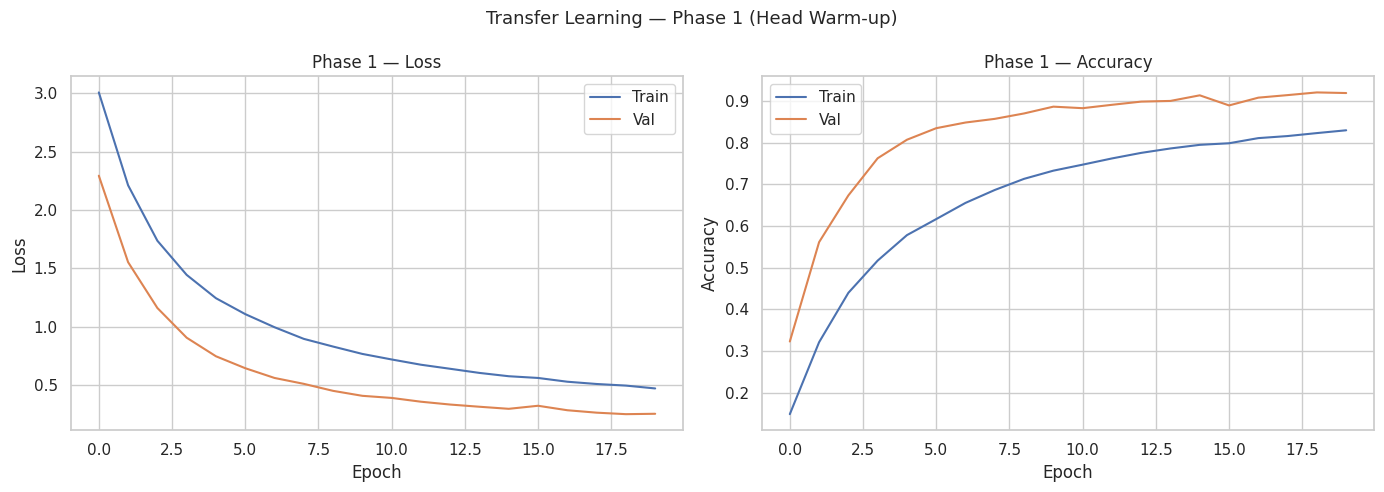

In [15]:
# Phase 1 training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_p1.history['loss'],     label='Train')
axes[0].plot(history_p1.history['val_loss'], label='Val')
axes[0].set_title('Phase 1 — Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history_p1.history['accuracy'],     label='Train')
axes[1].plot(history_p1.history['val_accuracy'], label='Val')
axes[1].set_title('Phase 1 — Accuracy')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.suptitle('Transfer Learning — Phase 1 (Head Warm-up)', fontsize=13)
plt.tight_layout()
plt.show()

## 11. Phase 2 — Full Fine-tuning (Unfreeze Everything)

Now that the new head has stabilized, we unfreeze all layers and continue training at a **much lower learning rate** (`1e-5`).
This lets the early conv layers make small adjustments to adapt to Paderborn's signal characteristics without "forgetting" what they learned from CWRU.

In [16]:
# Unfreeze ALL layers
for layer in tl_model.layers:
    layer.trainable = True

# Recompile at a much lower LR
tl_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR_PHASE2),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

total_params    = tl_model.count_params()
trainable_count = int(np.sum([np.prod(v.shape) for v in tl_model.trainable_variables]))
print(f"All {trainable_count:,} / {total_params:,} params now trainable.")

callbacks_p2 = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-8,
        verbose=1
    ),
    ModelCheckpoint(
        filepath='best_paderborn_tl_final.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
]

print("=" * 60)
print("PHASE 2 — Full Fine-tuning (all layers, lr=1e-5)")
print("=" * 60)

history_p2 = tl_model.fit(
    X_train, y_train_oh,
    validation_data=(X_val, y_val_oh),
    epochs=EPOCHS_PHASE2,
    batch_size=BATCH_SIZE,
    class_weight=class_weights_dict,
    callbacks=callbacks_p2,
    verbose=1
)

All 194,400 / 195,360 params now trainable.
PHASE 2 — Full Fine-tuning (all layers, lr=1e-5)
Epoch 1/30
840/840 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5853 - loss: 1.4224
Epoch 1: val_accuracy improved from -inf to 0.87346, saving model to best_paderborn_tl_final.keras
840/840 ━━━━━━━━━━━━━━━━━━━━ 22s 17ms/step - accuracy: 0.5854 - loss: 1.4220 - val_accuracy: 0.8735 - val_loss: 0.4121 - learning_rate: 1.0000e-05
Epoch 2/30
837/840 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7588 - loss: 0.6943
Epoch 2: val_accuracy improved from 0.87346 to 0.89504, saving model to best_paderborn_tl_final.keras
840/840 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.7589 - loss: 0.6942 - val_accuracy: 0.8950 - val_loss: 0.3393 - learning_rate: 1.0000e-05
Epoch 3/30
840/840 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7809 - loss: 0.6246
Epoch 3: val_accuracy improved from 0.89504 to 0.90392, saving model to best_paderborn_tl_final.keras
840/840 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accura

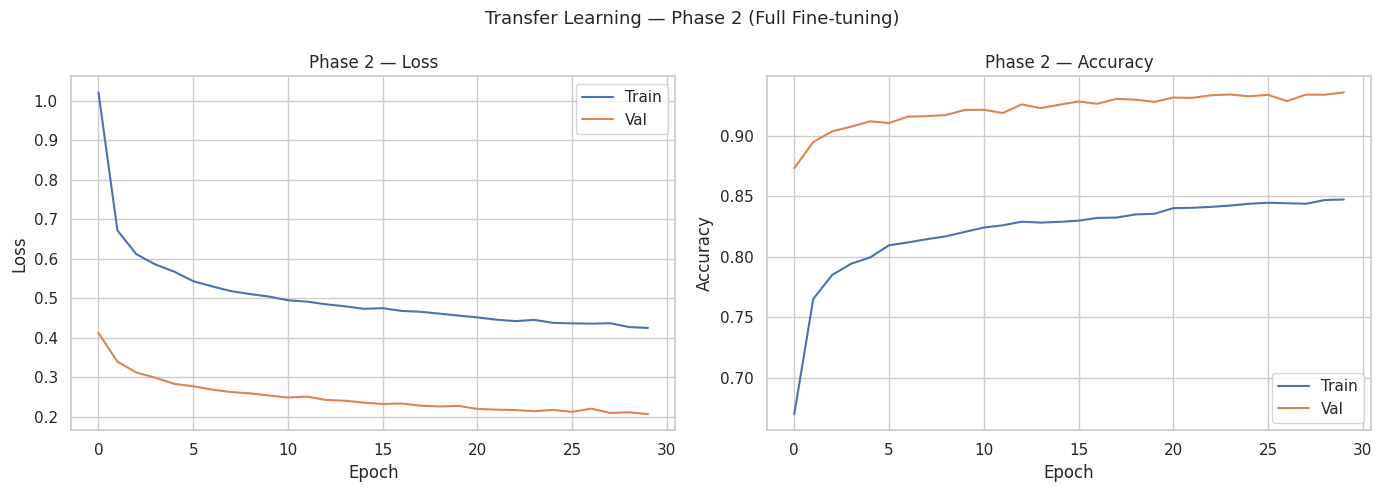

In [17]:
# Phase 2 training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_p2.history['loss'],     label='Train')
axes[0].plot(history_p2.history['val_loss'], label='Val')
axes[0].set_title('Phase 2 — Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history_p2.history['accuracy'],     label='Train')
axes[1].plot(history_p2.history['val_accuracy'], label='Val')
axes[1].set_title('Phase 2 — Accuracy')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.suptitle('Transfer Learning — Phase 2 (Full Fine-tuning)', fontsize=13)
plt.tight_layout()
plt.show()

## 12. Combined Training History (Phase 1 + Phase 2)

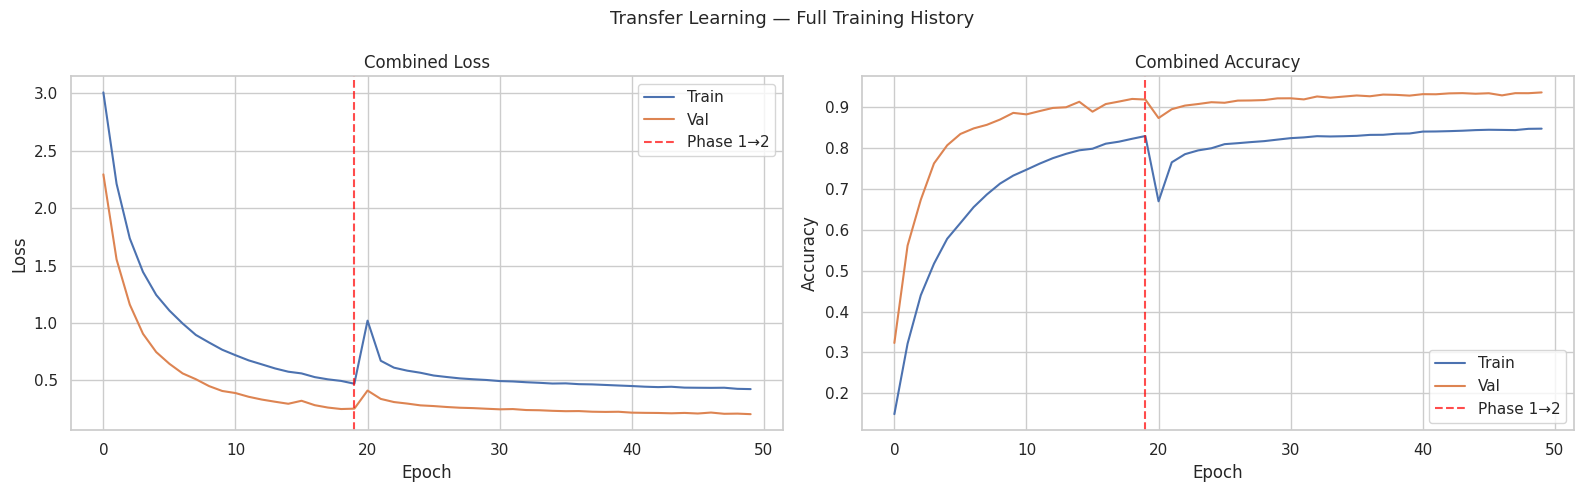

Phase 1 ended at epoch 20  (red dashed line)


In [18]:
# Stitch Phase 1 and Phase 2 histories together for a combined view
combined_loss     = history_p1.history['loss']     + history_p2.history['loss']
combined_val_loss = history_p1.history['val_loss'] + history_p2.history['val_loss']
combined_acc      = history_p1.history['accuracy']     + history_p2.history['accuracy']
combined_val_acc  = history_p1.history['val_accuracy'] + history_p2.history['val_accuracy']

phase1_end = len(history_p1.history['loss'])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, train, val, ylabel, title in [
    (axes[0], combined_loss, combined_val_loss, 'Loss', 'Loss'),
    (axes[1], combined_acc,  combined_val_acc,  'Accuracy', 'Accuracy'),
]:
    ax.plot(train, label='Train')
    ax.plot(val,   label='Val')
    ax.axvline(x=phase1_end - 1, color='red', linestyle='--', alpha=0.7, label='Phase 1→2')
    ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.set_title(f'Combined {title}')
    ax.legend()

plt.suptitle('Transfer Learning — Full Training History', fontsize=13)
plt.tight_layout()
plt.show()

print(f"Phase 1 ended at epoch {phase1_end}  (red dashed line)")

## 13. Evaluation on Test Set

In [19]:
# Load the best checkpoint saved during Phase 2
best_model = keras.models.load_model('best_paderborn_tl_final.keras')
print("Loaded best checkpoint: best_paderborn_tl_final.keras")

test_loss, test_acc = best_model.evaluate(X_test, y_test_oh, verbose=0)
print(f"\nTest Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f}")

y_pred_probs = best_model.predict(X_test)
y_pred       = np.argmax(y_pred_probs, axis=1)

print(f"\nWeighted F1   : {f1_score(y_test, y_pred, average='weighted'):.4f}")
print(f"Macro F1      : {f1_score(y_test, y_pred, average='macro'):.4f}")

Loaded best checkpoint: best_paderborn_tl_final.keras

Test Loss     : 0.1865
Test Accuracy : 0.9424
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step

Weighted F1   : 0.9424
Macro F1      : 0.9421


In [20]:
print("\nClassification Report:")
print("=" * 60)
print(classification_report(
    y_test, y_pred,
    target_names=label_encoder.classes_
))


Classification Report:
              precision    recall  f1-score   support

        K001       0.98      0.99      0.98       420
        K002       0.97      0.99      0.98       360
        K003       0.89      0.79      0.84       360
        K004       0.98      0.99      0.98       360
        K005       0.97      0.97      0.97       360
        K006       0.81      0.89      0.85       360
        KA01       1.00      1.00      1.00       360
        KA03       0.67      0.75      0.71       360
        KA04       1.00      1.00      1.00       360
        KA05       0.96      0.97      0.97       360
        KA06       0.99      1.00      0.99       360
        KA07       0.98      0.98      0.98       360
        KA08       0.99      0.98      0.99       360
        KA09       1.00      1.00      1.00       360
        KA15       0.92      0.82      0.87       360
        KA16       1.00      1.00      1.00       360
        KA22       0.84      0.93      0.88       360
   

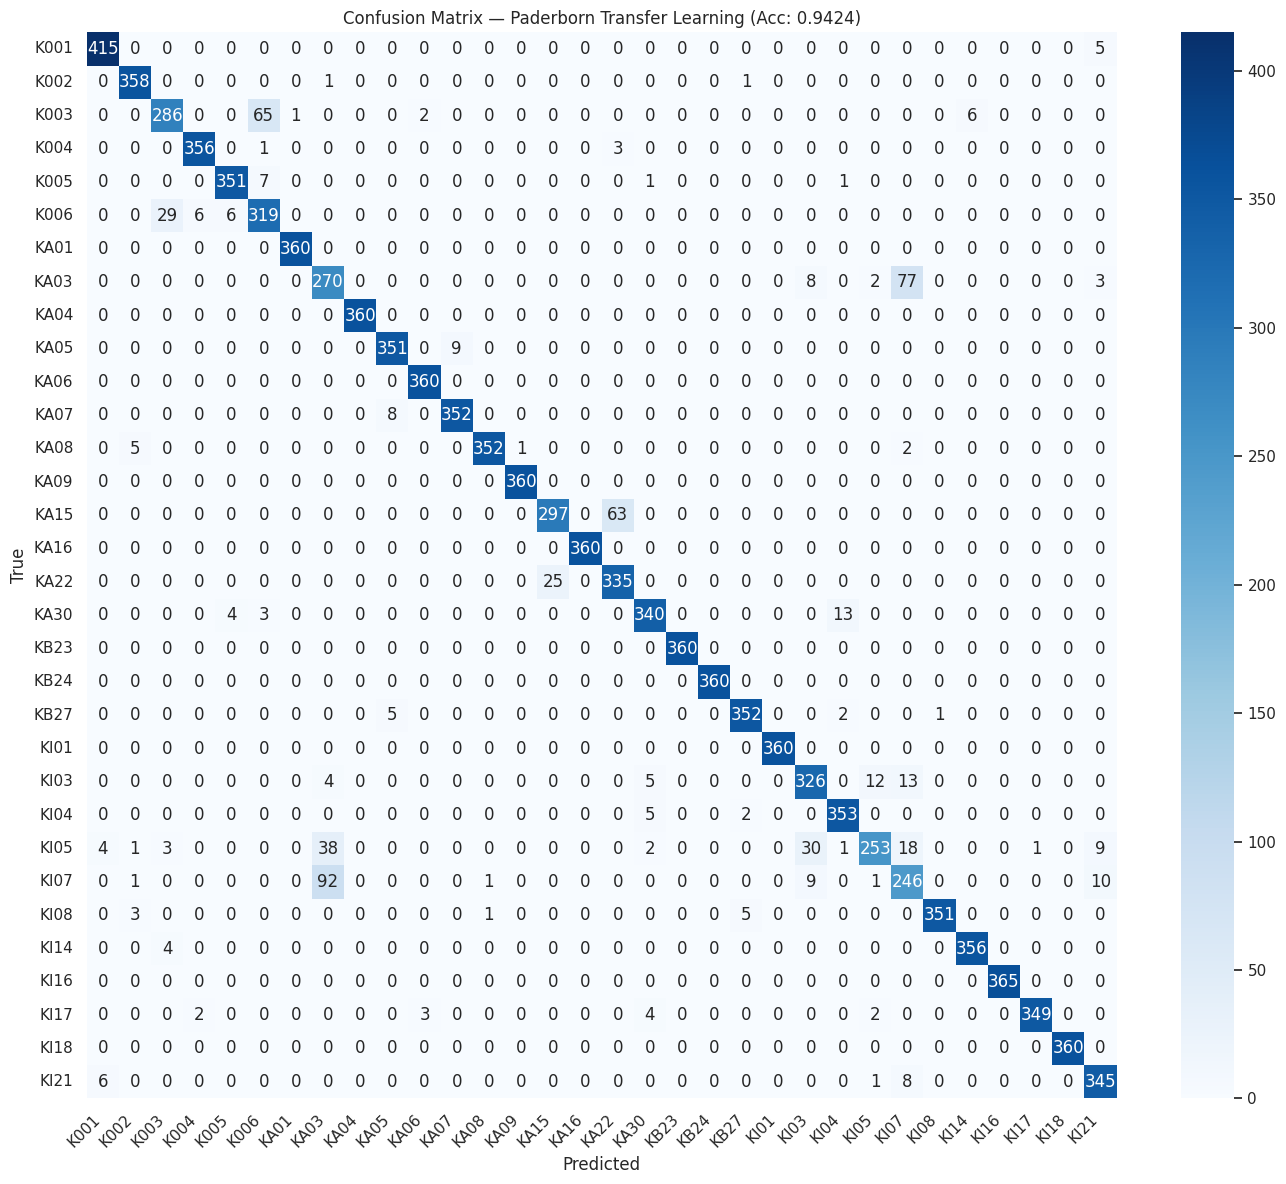

In [21]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(14, 12))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title(f'Confusion Matrix — Paderborn Transfer Learning (Acc: {test_acc:.4f})')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

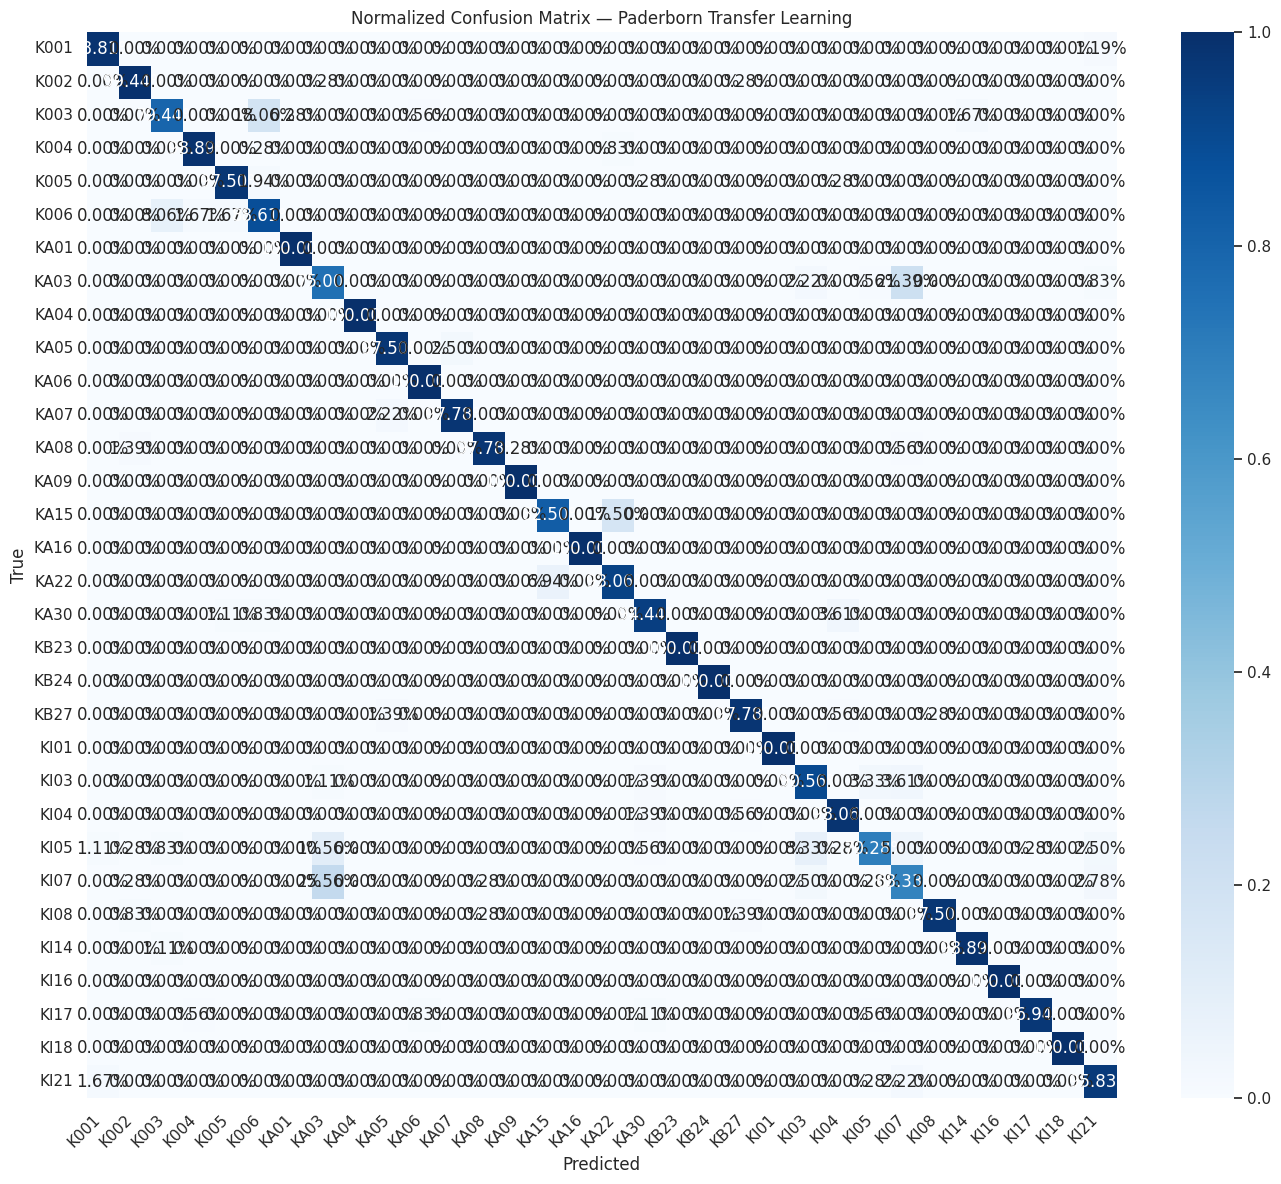

In [22]:
# Normalized Confusion Matrix
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(14, 12))
sns.heatmap(
    cm_norm, annot=True, fmt='.2%', cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title('Normalized Confusion Matrix — Paderborn Transfer Learning')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 14. Save Final Model

In [23]:
best_model.save('paderborn_tl_cnn_final.keras')
print("Final model saved as: paderborn_tl_cnn_final.keras")

Final model saved as: paderborn_tl_cnn_final.keras
